# Phase 3 - Exploratory Data Analysis

10 business questions. For each: run code -> make a chart -> write a 2-sentence
observation (**pattern + business implication**). A chart with no "so what?" is
just printed numbers. Figures are saved to `../outputs/figures/` for the README
and dashboard.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("../outputs/figures", exist_ok=True)

df = pd.read_csv("../data/cleaned/zomato_clean.csv")
cuisines = pd.read_csv("../data/cleaned/zomato_cuisines.csv")
print("Loaded:", df.shape, "| cuisines:", cuisines.shape)

Loaded: (224520, 12) | cuisines: (473264, 5)


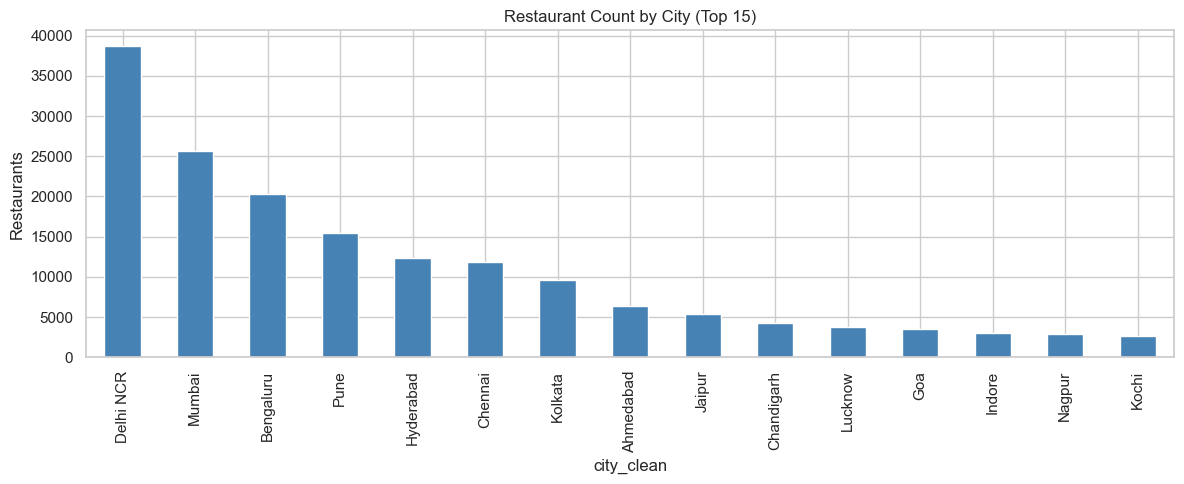

In [2]:
# Q1 - How are restaurants distributed across cities?
city_counts = df["city_clean"].value_counts().head(15)
ax = city_counts.plot(kind="bar", color="steelblue", figsize=(12, 5))
ax.set_title("Restaurant Count by City (Top 15)")
ax.set_ylabel("Restaurants")
plt.tight_layout()
plt.savefig("../outputs/figures/q1_city_counts.png", dpi=120)
plt.show()

**Observation (Q1):** Delhi NCR, Mumbai and Bengaluru dominate the restaurant
count - the metros are already saturated. A new entrant faces the fiercest
competition here, which pushes us to look at high-satisfaction Tier-2 cities later.

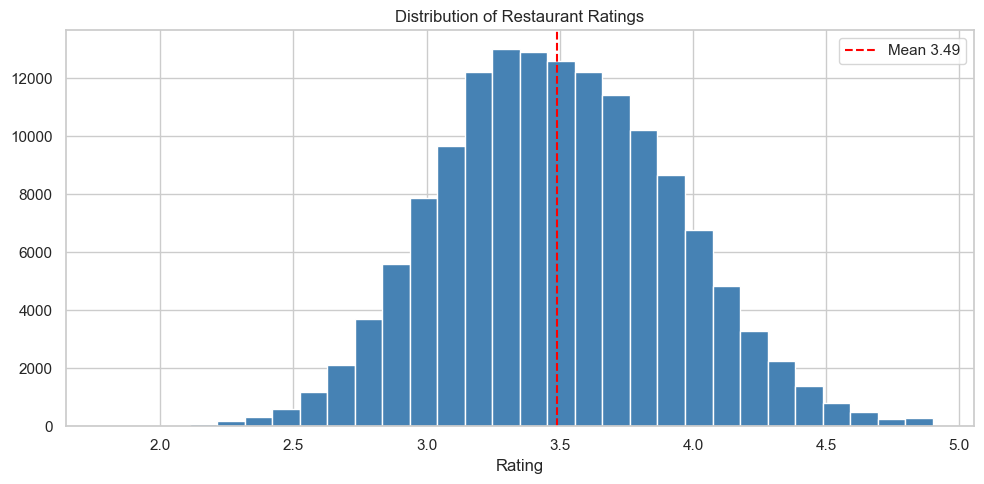

In [3]:
# Q2 - What is the rating distribution?
ax = df["rating"].hist(bins=30, color="steelblue", edgecolor="white", figsize=(10, 5))
ax.axvline(df["rating"].mean(), color="red", linestyle="--", label=f"Mean {df['rating'].mean():.2f}")
ax.set_title("Distribution of Restaurant Ratings")
ax.set_xlabel("Rating"); ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/q2_rating_dist.png", dpi=120)
plt.show()

**Observation (Q2):** Ratings cluster around 3.4-3.7, roughly bell-shaped but
slightly left-skewed. Very few restaurants sit below 2.5, so rating alone is a
weak differentiator - the interesting signal is at the high (4.0+) tail.

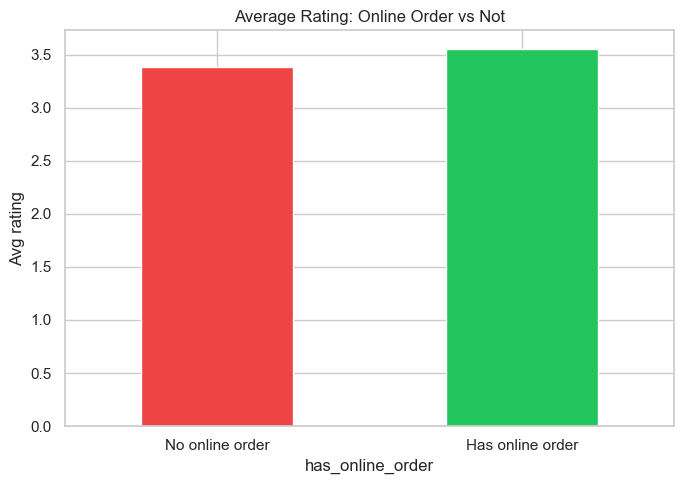

has_online_order
False    3.386703
True     3.552680
Name: rating, dtype: float64


In [4]:
# Q3 - Does online ordering correlate with higher ratings?
ax = df.groupby("has_online_order")["rating"].mean().plot(
    kind="bar", color=["#ef4444", "#22c55e"], figsize=(7, 5))
ax.set_title("Average Rating: Online Order vs Not")
ax.set_xticklabels(["No online order", "Has online order"], rotation=0)
ax.set_ylabel("Avg rating")
plt.tight_layout()
plt.savefig("../outputs/figures/q3_online_rating.png", dpi=120)
plt.show()
print(df.groupby("has_online_order")["rating"].mean())

**Observation (Q3):** Online-order-enabled restaurants rate noticeably higher on
average. This likely reflects digital maturity (better-run operations adopt
delivery), so online ordering is a useful proxy for operational readiness - not
proof it *causes* better food.

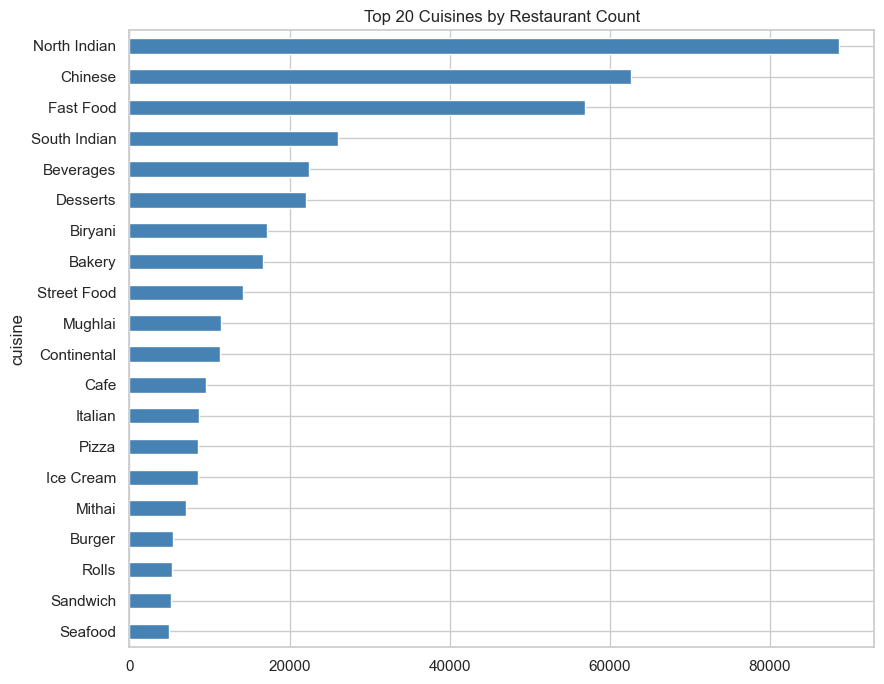

In [5]:
# Q4 - Which cuisines appear most often?
ax = cuisines["cuisine"].value_counts().head(20).plot(
    kind="barh", color="steelblue", figsize=(9, 7))
ax.set_title("Top 20 Cuisines by Restaurant Count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/q4_top_cuisines.png", dpi=120)
plt.show()

**Observation (Q4):** North Indian, Chinese and Fast Food dominate supply. A new
entrant in these categories competes with tens of thousands of restaurants, so
the opportunity is more likely in high-rated but lower-supply cuisines (Q7 gap analysis).

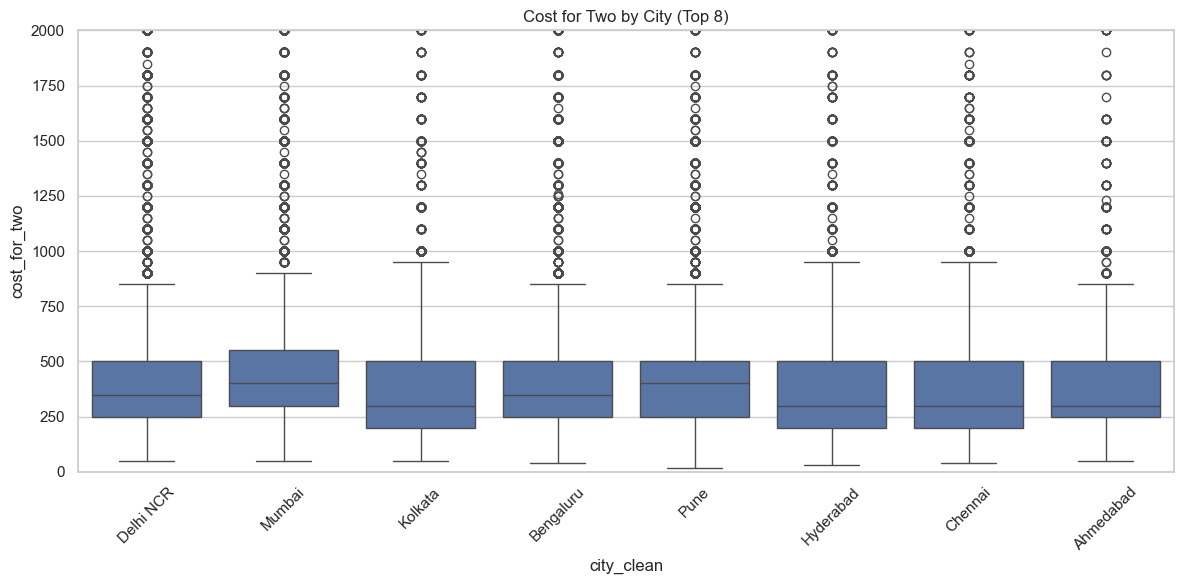

In [6]:
# Q5 - Cost distribution across the top cities
top_cities = df["city_clean"].value_counts().head(8).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df["city_clean"].isin(top_cities)],
            x="city_clean", y="cost_for_two")
plt.ylim(0, 2000)
plt.xticks(rotation=45)
plt.title("Cost for Two by City (Top 8)")
plt.tight_layout()
plt.savefig("../outputs/figures/q5_cost_by_city.png", dpi=120)
plt.show()

**Observation (Q5):** Mumbai and Delhi NCR carry the highest median cost-for-two;
most cities cluster around 300-500 INR. Pricing strategy should be city-specific -
a "premium" price in one city is mid-range in another.

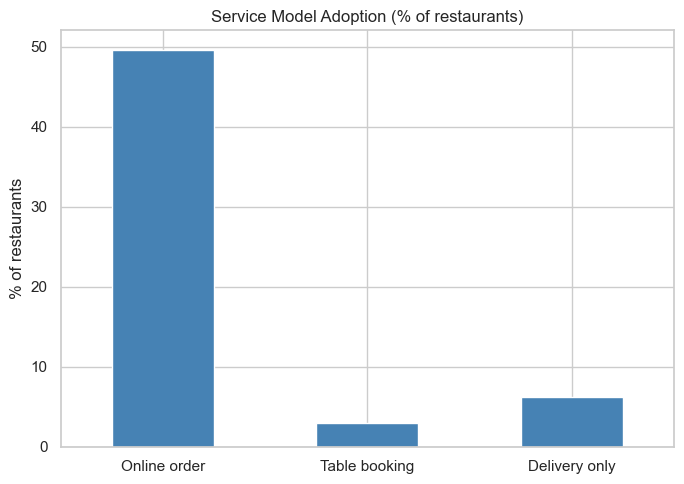

                pct
Online order   49.6
Table booking   2.9
Delivery only   6.3


In [7]:
# Q6 - Service model mix: online order / table booking / delivery only
service = pd.DataFrame({
    "Online order":  [df["has_online_order"].mean() * 100],
    "Table booking": [df["has_table_booking"].mean() * 100],
    "Delivery only": [df["delivery_only"].mean() * 100],
}).T.rename(columns={0: "pct"})
ax = service["pct"].plot(kind="bar", color="steelblue", figsize=(7, 5))
ax.set_title("Service Model Adoption (% of restaurants)")
ax.set_ylabel("% of restaurants"); plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/q6_service_mix.png", dpi=120)
plt.show()
print(service.round(1))

**Observation (Q6):** About half of restaurants offer online ordering, but table
booking and delivery-only models are rare. The delivery-first (cloud-kitchen)
model is still under-penetrated - room for a delivery-native brand.

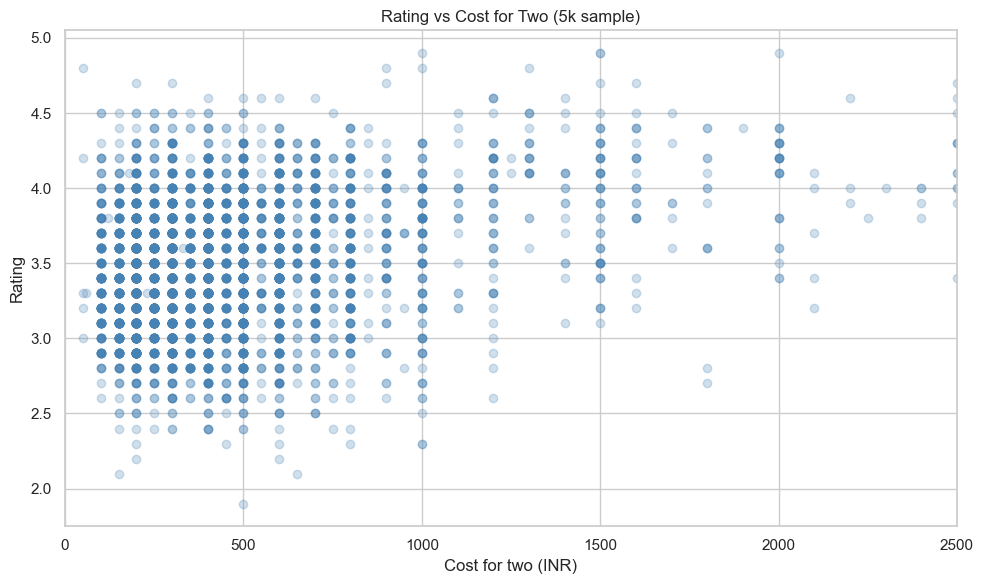

Correlation: 0.27


In [8]:
# Q7 - Rating vs cost relationship
sample = df.dropna(subset=["rating", "cost_for_two"]).sample(
    min(5000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample["cost_for_two"], sample["rating"], alpha=0.25, color="steelblue")
plt.xlim(0, 2500)
plt.title("Rating vs Cost for Two (5k sample)")
plt.xlabel("Cost for two (INR)"); plt.ylabel("Rating")
plt.tight_layout()
plt.savefig("../outputs/figures/q7_rating_vs_cost.png", dpi=120)
plt.show()
print("Correlation:", round(df["rating"].corr(df["cost_for_two"]), 3))

**Observation (Q7):** Cost and rating are only weakly related - expensive is not
reliably better-rated. Indian diners appear to reward value-for-money, so a brand
can win on consistency and price rather than premium positioning.

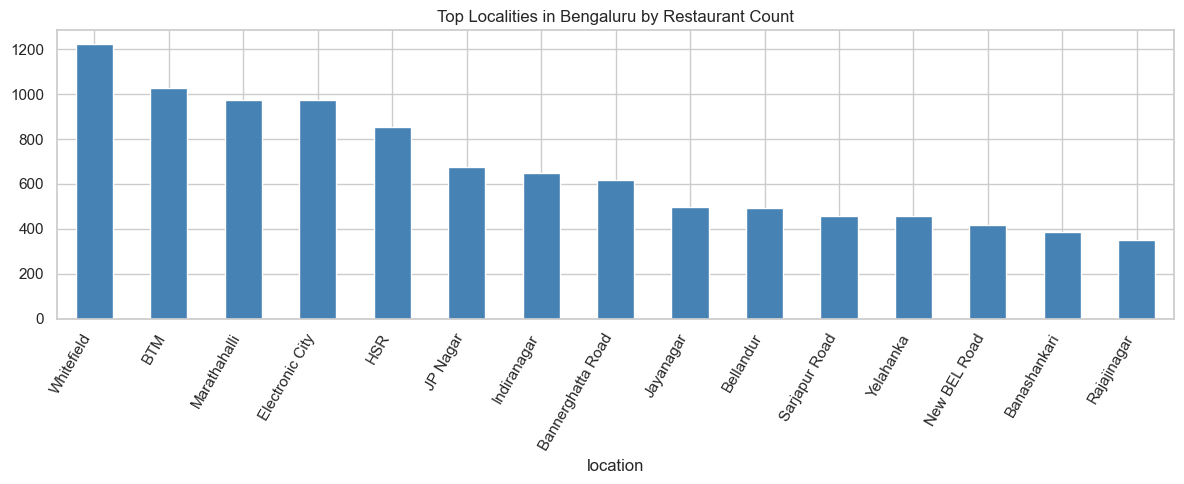

In [9]:
# Q8 - Top localities in Bengaluru by restaurant density
blr = df[df["city_clean"] == "Bengaluru"]["location"].value_counts().head(15)
ax = blr.plot(kind="bar", color="steelblue", figsize=(12, 5))
ax.set_title("Top Localities in Bengaluru by Restaurant Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/q8_blr_localities.png", dpi=120)
plt.show()

**Observation (Q8):** A handful of Bengaluru localities concentrate a large share
of restaurants (classic clustering). These hotspots are over-served; the site-selection
opportunity is in adjacent, under-served localities with similar demand.

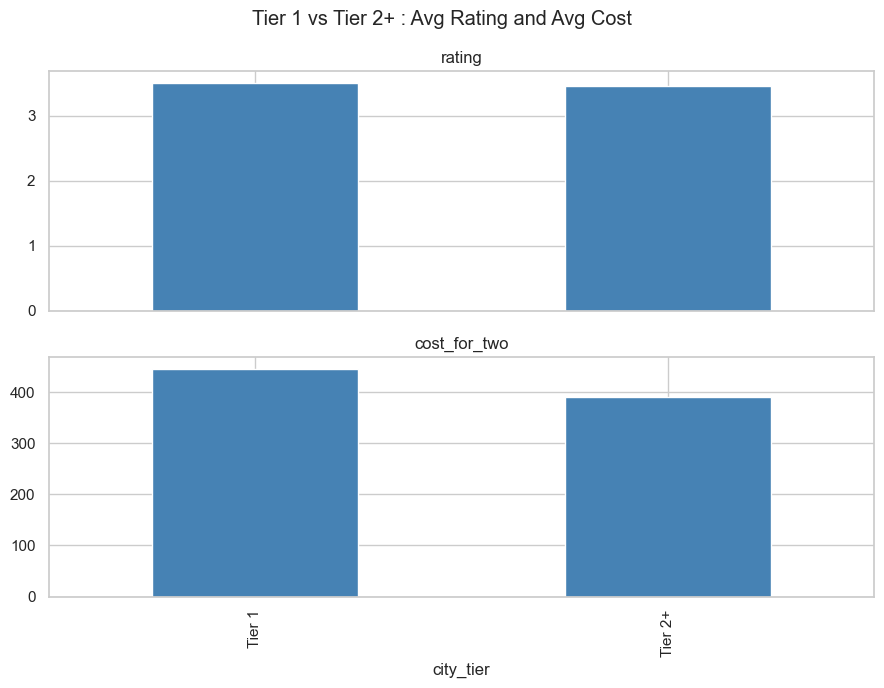

           rating  cost_for_two
city_tier                      
Tier 1       3.51        445.51
Tier 2+      3.45        390.97


In [10]:
# Q9 - Tier 1 vs Tier 2+ : rating and cost comparison
comp = df.groupby("city_tier")[["rating", "cost_for_two"]].mean()
comp.plot(kind="bar", subplots=True, figsize=(9, 7), legend=False, color="steelblue")
plt.suptitle("Tier 1 vs Tier 2+ : Avg Rating and Avg Cost")
plt.tight_layout()
plt.savefig("../outputs/figures/q9_tier_compare.png", dpi=120)
plt.show()
print(comp.round(2))

**Observation (Q9):** Tier 2+ cities post ratings comparable to (sometimes above)
Tier 1 metros, but at lower cost. That means quality-per-rupee is strong in Tier 2 -
supporting an expansion thesis away from the saturated metros.

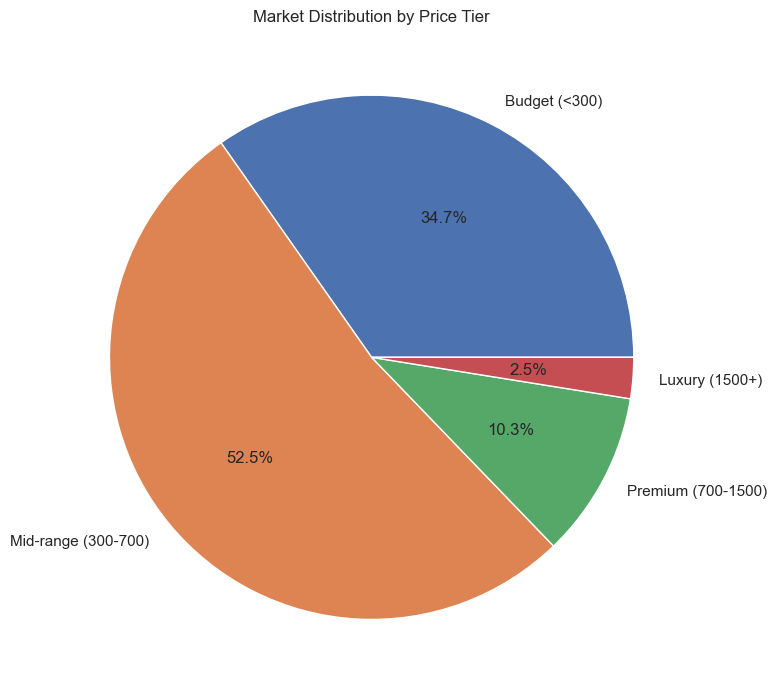

In [11]:
# Q10 - Market distribution by price tier
order = ["Budget (<300)", "Mid-range (300-700)", "Premium (700-1500)", "Luxury (1500+)"]
counts = df["price_tier"].value_counts().reindex(order).dropna()
ax = counts.plot(kind="pie", autopct="%1.1f%%", figsize=(8, 8), ylabel="")
ax.set_title("Market Distribution by Price Tier")
plt.tight_layout()
plt.savefig("../outputs/figures/q10_price_tier_pie.png", dpi=120)
plt.show()

**Observation (Q10):** The market is overwhelmingly Budget + Mid-range; Premium and
Luxury are a small slice. Yet Q4's SQL shows the high-rated *share* rises with price
tier - so Premium is under-supplied relative to how well it performs, a genuine gap.

---
### EDA summary
Headline: **cost does not buy ratings**, metros are saturated, and Tier-2 cities
deliver strong quality-per-rupee. These three findings drive the SQL opportunity
scoring in Phase 4.